#  Bureaux Vente — Marrakech

## Imports & Configuration

In [1]:
import os, sys, json, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from datetime import datetime
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

PIPELINE_DIR = os.path.abspath("../../pipeline/ventes")
if PIPELINE_DIR not in sys.path:
    sys.path.insert(0, PIPELINE_DIR)

RAW_PATH   = "../../data/marrakech_immo_vente/bureaux_vente.csv"
CLEAN_PATH = "../../data/cleaned_data/vente/bureaux_vente_final.csv"
MODEL_PATH = "../../model_training/models/xgb_bureaux_vente.pkl"
META_PATH  = "../../model_training/models/xgb_bureaux_vente_metadata.json"
print(" Imports OK")


/home/nouhayla/Desktop/stage/gateone-deploy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Imports OK


In [2]:
"""
diag_bureaux.py — Diagnostic filtres load_data()
Colle ce code dans une cellule notebook OU lance : python diag_bureaux.py
"""
import numpy as np
import pandas as pd
from pathlib import Path

# ── Adapte ce chemin si besoin ──
CSV = Path("../../data/marrakech_immo_vente/bureaux_vente.csv")

df = pd.read_csv(CSV)

print("=" * 55)
print(f"COLONNES : {df.columns.tolist()}")
print("=" * 55)
print(f"\n0. Brut : {len(df)} lignes\n")

# ── Détection colonnes ──
surf_col  = next((c for c in ["surface_num","surface","superficie"] if c in df.columns), None)
price_col = next((c for c in ["prix","prix_num","price"] if c in df.columns), None)

print(f"   → colonne surface détectée : '{surf_col}'")
print(f"   → colonne prix   détectée : '{price_col}'\n")

# ── Stats brutes ──
s = pd.to_numeric(df[surf_col], errors="coerce")
p = pd.to_numeric(df[price_col], errors="coerce")
print(f"Surface brute  : min={s.min():.1f}  median={s.median():.1f}  max={s.max():.1f}  NaN={s.isna().sum()}")
print(f"Prix brut      : min={p.min():,.0f}  median={p.median():,.0f}  max={p.max():,.0f}  NaN={p.isna().sum()}")

# ── Hypothèse : prix = prix/m² (pas prix total) ──
prix_x_surf = p * s
print(f"\nSi prix=pm² → prix_num synthétique : median={prix_x_surf.median():,.0f}  max={prix_x_surf.max():,.0f}")

# ── Filtre 1 : surface ──
df2 = df.copy()
df2["surface_num"] = pd.to_numeric(df2[surf_col], errors="coerce")
n_before = len(df2)
out_nan  = df2["surface_num"].isna().sum()
out_low  = (df2["surface_num"] < 5).sum()
out_high = (df2["surface_num"] > 5000).sum()
df2 = df2[df2["surface_num"].between(5, 5000)]
print(f"\n1. Filtre surface [5, 5000]  : {n_before} → {len(df2)}  "
      f"(NaN={out_nan}, <5={out_low}, >5000={out_high})")

# ── Filtre 2 : prix ──
df2["prix_num"] = pd.to_numeric(df2[price_col], errors="coerce")
n_before = len(df2)
out_nan  = df2["prix_num"].isna().sum()
out_low  = (df2["prix_num"] < 50_000).sum()
out_high = (df2["prix_num"] > 50_000_000).sum()
df2 = df2[df2["prix_num"].between(50_000, 50_000_000)]
print(f"2. Filtre prix  [50k, 50M]   : {n_before} → {len(df2)}  "
      f"(NaN={out_nan}, <50k={out_low}, >50M={out_high})")

# ── Filtre 3 : pm² ──
df2["prix_m2"] = df2["prix_num"] / df2["surface_num"]
n_before = len(df2)
out_low  = (df2["prix_m2"] < 1_000).sum()
out_high = (df2["prix_m2"] > 200_000).sum()
df2 = df2[df2["prix_m2"].between(1_000, 200_000)]
print(f"3. Filtre pm²   [1k, 200k]   : {n_before} → {len(df2)}  "
      f"(<1k={out_low}, >200k={out_high})")

# ── Distribution finale ──
if len(df2) > 0:
    print(f"\n   Survivants — surface : p5={df2['surface_num'].quantile(.05):.0f}  "
          f"median={df2['surface_num'].median():.0f}  p95={df2['surface_num'].quantile(.95):.0f}")
    print(f"   Survivants — prix    : p5={df2['prix_num'].quantile(.05):,.0f}  "
          f"median={df2['prix_num'].median():,.0f}  p95={df2['prix_num'].quantile(.95):,.0f}")
    print(f"   Survivants — pm²     : p5={df2['prix_m2'].quantile(.05):,.0f}  "
          f"median={df2['prix_m2'].median():,.0f}  p95={df2['prix_m2'].quantile(.95):,.0f}")

# ── Exemples lignes tuées par pm² ──
df_tmp = df.copy()
df_tmp["surface_num"] = pd.to_numeric(df_tmp[surf_col], errors="coerce")
df_tmp = df_tmp[df_tmp["surface_num"].between(5, 5000)]
df_tmp["prix_num"] = pd.to_numeric(df_tmp[price_col], errors="coerce")
df_tmp = df_tmp[df_tmp["prix_num"].between(50_000, 50_000_000)]
df_tmp["prix_m2"] = df_tmp["prix_num"] / df_tmp["surface_num"]

killed_high = df_tmp[df_tmp["prix_m2"] > 200_000].nlargest(5, "prix_m2")
killed_low  = df_tmp[df_tmp["prix_m2"] < 1_000].nsmallest(5, "prix_m2")

cols_show = [c for c in [surf_col, price_col, "prix_m2", "segment_prix", "zone_clean"] if c in df_tmp.columns]
if len(killed_high):
    print(f"\n── Top 5 tués pm² > 200k ──")
    print(killed_high[cols_show].to_string())
if len(killed_low):
    print(f"\n── Top 5 tués pm² < 1k ──")
    print(killed_low[cols_show].to_string())

COLONNES : ['id', 'titre', 'prix', 'localisation', 'type_bien', 'surface', 'chambres', 'salles_bain', 'description', 'agence', 'url', 'source', 'piscine', 'parking', 'ascenseur', 'terrasse', 'jardin', 'climatisation', 'securite', 'vue', 'meuble', 'neuf', 'cave', 'hammam', 'etage', 'surface_terrain', 'prix_num', 'surface_num', 'chambres_num', 'salles_bain_num', 'nb_pieces', 'quartier', 'prix_m2', 'prix_m2_median_quartier']

0. Brut : 241 lignes

   → colonne surface détectée : 'surface_num'
   → colonne prix   détectée : 'prix'

Surface brute  : min=0.0  median=65.0  max=2400.0  NaN=66
Prix brut      : min=400,000  median=1,000,000  max=4,100,000  NaN=230

Si prix=pm² → prix_num synthétique : median=62,000,000  max=966,000,000

1. Filtre surface [5, 5000]  : 241 → 173  (NaN=66, <5=2, >5000=0)
2. Filtre prix  [50k, 50M]   : 173 → 11  (NaN=162, <50k=0, >50M=0)
3. Filtre pm²   [1k, 200k]   : 11 → 11  (<1k=0, >200k=0)

   Survivants — surface : p5=34  median=66  p95=284
   Survivants — prix

## 1. Chargement via pip_bureaux

In [3]:
from pip_bureaux import (
    load_data, split_and_encode, build_pipeline, train,
    evaluate, plot_results, predict_price,
    NUMERIC_FEATURES, BINARY_FEATURES, CATEGORICAL_FEATURES, TARGET_LOG
)

df = load_data(RAW_PATH)
print(f"\nZones :")
print(df["zone_clean"].value_counts())
print(f"\nType local :")
print(df["segment_prix"].value_counts())


 Chargement : 241 lignes, 34 colonnes
   Total initial : 241
   Après filtres : 138 lignes
   Prix médian    : 1,100,000 MAD
   Surface médiane: 67 m²
   pm² médian     : 16,277 MAD/m²

Zones :
zone_clean
Guéliz                 77
Massira                15
Autre                  13
Issil/Majorelle        12
Hivernage               7
Targa                   5
Route de Safi           4
Route de Casablanca     4
Médina                  1
Name: count, dtype: int64

Type local :
segment_prix
mid        102
premium     30
ultra        3
eco          3
Name: count, dtype: int64


In [4]:
# ── Colonnes manquantes pour la cellule L ──
import numpy as np

# prix_num = prix/m²
if "prix_num" not in df.columns:
    df["prix_num"] = df["prix_num"] # already done in load_data

# log_prix
if "log_prix" not in df.columns:
    df["log_prix"] = np.log(df["prix_num"].replace(0, np.nan))

# zone_clean (si pas encore créée)
if "zone_clean" not in df.columns:
    if "quartier" in df.columns and df["quartier"].notna().sum() > len(df) * 0.3:
        df["zone_clean"] = df["quartier"].fillna("inconnu")
    elif "localisation" in df.columns:
        df["zone_clean"] = df["localisation"].fillna("inconnu")
    else:
        df["zone_clean"] = "inconnu"
    import unicodedata
    def normalize_text(s):
        if not isinstance(s, str): return s
        return unicodedata.normalize("NFKD", s).encode("ascii","ignore").decode().strip().lower()
    df["zone_clean"] = df["zone_clean"].apply(normalize_text)

# segment_prix (si pas encore créée)
if "segment_prix" not in df.columns:
    df["segment_prix"] = "local_comm"

print(f"prix_num     : {df['prix_num'].notna().sum()} valeurs — médian {df['prix_num'].median():,.0f}")
print(f"log_prix : {df['log_prix'].notna().sum()} valeurs")
print(f"zones   : {df['zone_clean'].nunique()} — {df['zone_clean'].value_counts().head(5).to_dict()}")
print(f"types   : {df['segment_prix'].value_counts().to_dict()}")

prix_num     : 138 valeurs — médian 1,100,000
log_prix : 138 valeurs
zones   : 9 — {'Guéliz': 77, 'Massira': 15, 'Autre': 13, 'Issil/Majorelle': 12, 'Hivernage': 7}
types   : {'mid': 102, 'premium': 30, 'ultra': 3, 'eco': 3}


## 2. EDA

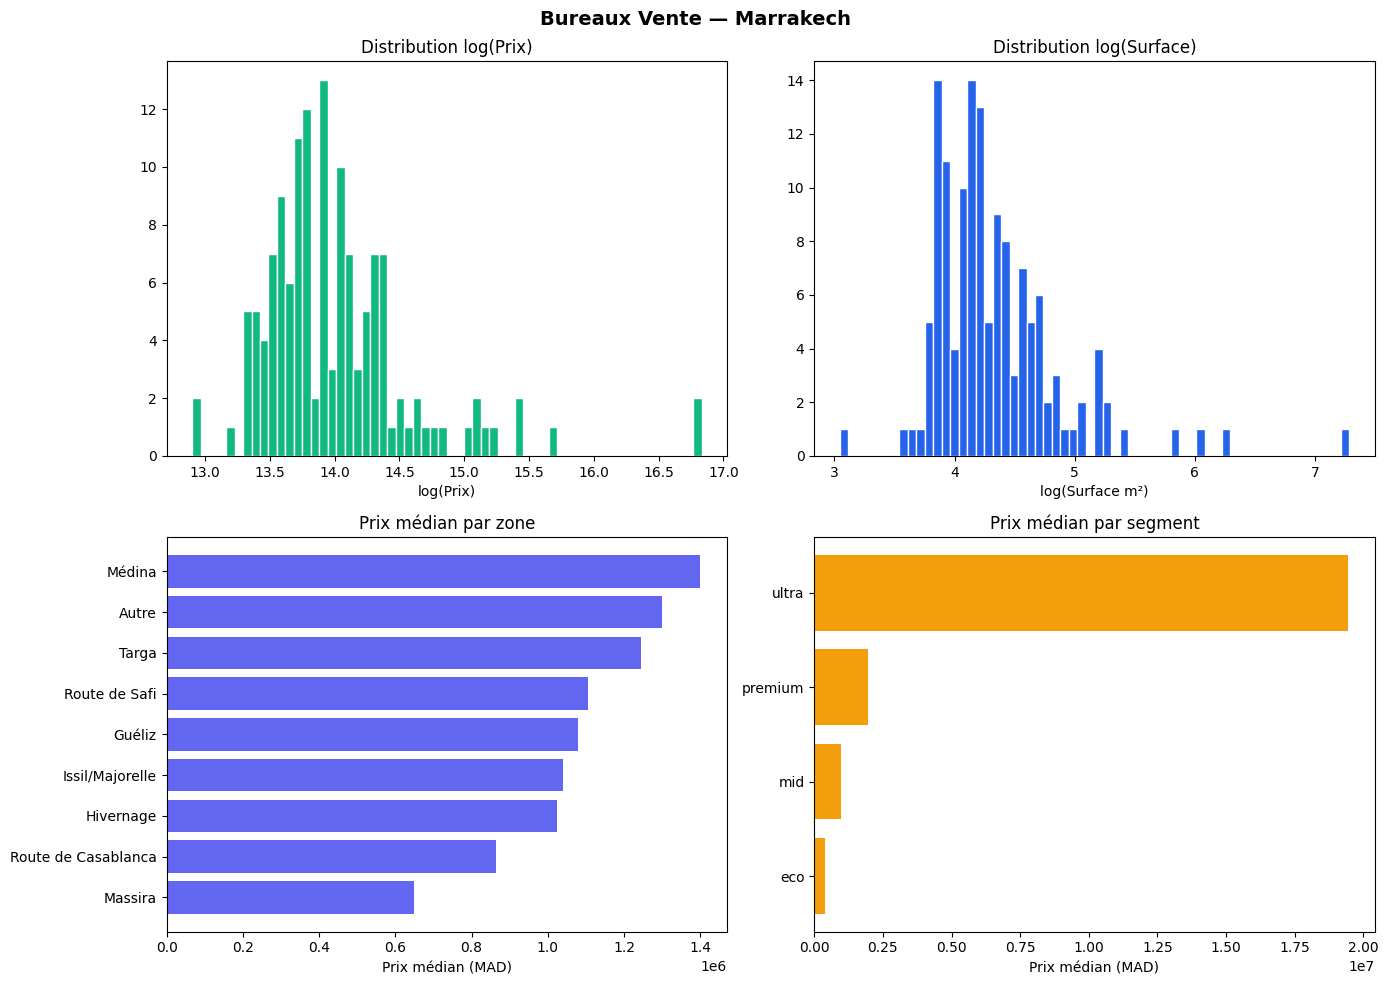


=== Prix médian par zone ===
                        median  count
zone_clean                           
Médina               1400000.0      1
Autre                1300000.0     13
Targa                1245000.0      5
Route de Safi        1105500.0      4
Guéliz               1080000.0     77
Issil/Majorelle      1040000.0     12
Hivernage            1024000.0      7
Route de Casablanca   865000.0      4
Massira               650000.0     15

=== Prix médian par segment_prix ===
                  median        std  count
segment_prix                              
ultra         19440000.0  7766725.0      3
premium        1950000.0  1007112.0     30
mid             980000.0   247822.0    102
eco             400000.0    69282.0      3

=== Corrélation features → log(pm²) ===
surface_num    0.714
etage          0.136
Name: log_prix, dtype: float64


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Bureaux Vente — Marrakech", fontsize=14, fontweight="bold")

axes[0,0].hist(df["log_prix"], bins=60, color="#10B981", edgecolor="white")
axes[0,0].set_title("Distribution log(Prix)"); axes[0,0].set_xlabel("log(Prix)")

axes[0,1].hist(np.log1p(df["surface_num"]), bins=60, color="#2563EB", edgecolor="white")
axes[0,1].set_title("Distribution log(Surface)"); axes[0,1].set_xlabel("log(Surface m²)")

med = df.groupby("zone_clean")["prix_num"].median().sort_values(ascending=True)
axes[1,0].barh(med.index, med.values, color="#6366F1")
axes[1,0].set_xlabel("Prix médian (MAD)"); axes[1,0].set_title("Prix médian par zone")

med_type = df.groupby("segment_prix")["prix_num"].median().sort_values(ascending=True)
axes[1,1].barh([str(x) for x in med_type.index], med_type.values, color="#F59E0B")
axes[1,1].set_xlabel("Prix médian (MAD)"); axes[1,1].set_title("Prix médian par segment")

plt.tight_layout(); plt.show()

print("\n=== Prix médian par zone ===")
print(df.groupby("zone_clean")["prix_num"]
      .agg(["median","count"]).sort_values("median",ascending=False).round(0))

print("\n=== Prix médian par segment_prix ===")
print(df.groupby("segment_prix")["prix_num"]
      .agg(["median","std","count"]).sort_values("median",ascending=False).round(0))

print("\n=== Corrélation features → log(pm²) ===")
num_check = ["surface_num","score_local","kw_industriel","kw_bureau",
             "kw_depot","kw_salle","kw_angle","kw_hotel","etage"]
avail = [c for c in num_check if c in df.columns]
print(df[avail+["log_prix"]].corr()["log_prix"].drop("log_prix")
      .sort_values(ascending=False).round(3))


## 3. Split + Target Encoding (sans leakage)

In [6]:
X_train, X_test, y_train, y_test, df_train, df_test, stats = split_and_encode(
    df, test_size=0.2, random_state=42
)
print(f"\nFeatures ({len(NUMERIC_FEATURES+BINARY_FEATURES+CATEGORICAL_FEATURES)}) :")
print(f"  Numériques  ({len(NUMERIC_FEATURES)}) : {NUMERIC_FEATURES}")
print(f"  Binaires    ({len(BINARY_FEATURES)}) : {BINARY_FEATURES}")
print(f"  Catégoriels ({len(CATEGORICAL_FEATURES)}) : {CATEGORICAL_FEATURES}")



Features (45) :
  Numériques  (28) : ['surface_num', 'log_surface', 'surface_par_piece', 'chambres_num', 'salles_bain_num', 'nb_pieces', 'etage_num', 'etage_known', 'score_standing', 'score_confort', 'nb_equipements', 'surf_x_standing', 'kw_open_space', 'kw_centre_affaires', 'kw_standing', 'kw_neuf', 'kw_titre', 'kw_renove', 'kw_ascenseur', 'kw_parking', 'te_log_prix_zone', 'te_log_prix_loc', 'pm2_median_zone', 'pm2_median_loc', 'surface_relative', 'surface_x_loc', 'log_prix_estime', 'zone_bias']
  Binaires    (13) : ['piscine', 'parking', 'ascenseur', 'terrasse', 'jardin', 'climatisation', 'securite', 'vue', 'meuble', 'neuf', 'cave', 'hammam', 'is_particulier']
  Catégoriels (4) : ['zone_clean', 'localisation_fine', 'segment_prix', 'cat_surface']


In [7]:
X_train, X_test, y_train, y_test, df_train, df_test, stats = split_and_encode(
    df, test_size=0.2, random_state=42
)
# stats est maintenant rempli → on peut construire le pipeline
pipeline = build_pipeline(stats)

## 4. Baseline

In [8]:
pipeline_baseline = build_pipeline(X_train)
pipeline_baseline = train(pipeline_baseline, X_train, y_train)
metrics_baseline  = evaluate(pipeline_baseline, X_test, y_test, df_test)


 Entraînement...



═════════════════════════════════════════════
  MÉTRIQUES — BUREAUX VENTE
═════════════════════════════════════════════
  MAE              :         803,375 MAD
  RMSE             :       3,173,711 MAD
  R²               :          0.6642
  MAPE             :           21.61 %
  CV R² (5 folds)  : -0.0573 ± 0.9449
═════════════════════════════════════════════


## 5. Optuna — 150 trials



In [9]:
num_cols = [c for c in NUMERIC_FEATURES     if c in X_train.columns]
bin_cols = [c for c in BINARY_FEATURES      if c in X_train.columns]
cat_cols = [c for c in CATEGORICAL_FEATURES if c in X_train.columns]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                                              num_cols),
    ("bin", "passthrough",                                                 bin_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),   cat_cols),
], remainder="drop")
preprocessor.fit(X_train)

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 300, 4000),
        learning_rate     = trial.suggest_float("learning_rate", 0.003, 0.08, log=True),
        max_depth         = trial.suggest_int("max_depth", 2, 8),
        max_leaves        = trial.suggest_int("max_leaves", 8, 63),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 2, 20),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        gamma             = trial.suggest_float("gamma", 0, 5),
        tree_method       = "hist",
    )
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(**params, random_state=42, n_jobs=-1)),
    ])
    return cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2", n_jobs=-1).mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"\n Meilleur R² CV : {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k:25s} : {v}")


  0%|                                                   | 0/150 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.37139:   0%|               | 0/150 [00:02<?, ?it/s]

Best trial: 0. Best value: 0.37139:   1%|       | 1/150 [00:02<06:28,  2.61s/it]

Best trial: 1. Best value: 0.373371:   1%|      | 1/150 [00:04<06:28,  2.61s/it]

Best trial: 1. Best value: 0.373371:   1%|      | 2/150 [00:04<05:02,  2.04s/it]

...

Best trial: 117. Best value: 0.666109:  99%|█▉| 149/150 [01:01<00:00,  2.48it/s]

Best trial: 117. Best value: 0.666109:  99%|█▉| 149/150 [01:01<00:00,  2.48it/s]

Best trial: 117. Best value: 0.666109: 100%|██| 150/150 [01:01<00:00,  2.44it/s]

Best trial: 117. Best value: 0.666109: 100%|██| 150/150 [01:01<00:00,  2.43it/s]


 Meilleur R² CV : 0.6661
  n_estimators              : 3463
  learning_rate             : 0.0436777172762083
  max_depth                 : 8
  max_leaves                : 10
  subsample                 : 0.6437266548339001
  colsample_bytree          : 0.5567639700077435
  colsample_bylevel         : 0.8004719755711601
  min_child_weight          : 2
  reg_alpha                 : 0.0001470964679796702
  reg_lambda                : 0.031203840673982172
  gamma                     : 0.010749269563433146


In [10]:
# Alias colonnes pour compatibilité notebook ↔ pipeline
import numpy as np

if "log_prix" not in df.columns and "log_prix_num" in df.columns:
    df["log_prix"] = df["log_prix_num"]

if "log_prix" not in df.columns and "prix_num" in df.columns:
    df["log_prix"] = np.log(df["prix_num"])

# Vérification segment_prix — si tout est local_comm, forcer depuis titre
print(df["segment_prix"].value_counts())
print(f"Colonnes dispo : {[c for c in df.columns if 'kw_' in c or c=='segment_prix']}")

segment_prix
mid        102
premium     30
ultra        3
eco          3
Name: count, dtype: int64
Colonnes dispo : ['kw_open_space', 'kw_centre_affaires', 'kw_standing', 'kw_neuf', 'kw_titre', 'kw_renove', 'kw_ascenseur', 'kw_parking', 'segment_prix']


In [11]:
# ── Diagnostic complet ───────────────────────────────────────────────────
import numpy as np

print(f"Taille X_train : {X_train.shape}")
print(f"Taille X_test  : {X_test.shape}")
print(f"Zones dans train : {X_train['zone_clean'].nunique()}")
print(f"Zones dans test  : {X_test['zone_clean'].nunique()}")

print("\n=== Variance log_prix par zone ===")
print(df.groupby("zone_clean")["log_prix"]
      .agg(["mean","std","count"]).sort_values("std",ascending=False).round(3))

print("\n=== Variance log_prix par segment_prix ===")
print(df.groupby("segment_prix")["log_prix"]
      .agg(["mean","std","count"]).sort_values("std",ascending=False).round(3))

corr_surf      = np.log1p(df["surface_num"]).corr(df["log_prix"])
corr_surf_prix = np.log1p(df["surface_num"]).corr(df["log_prix"])   # ← log_prix maintenant dispo
print(f"\n  log_surface → log_prix  : {corr_surf:.3f}")
print(f"  log_surface → log_prix : {corr_surf_prix:.3f}")

# ── PATCH 1 : pipeline_final n'existe pas encore ici → utiliser pipeline_baseline ──
_pipeline = pipeline_final if "pipeline_final" in dir() else pipeline_baseline

# ── PATCH 2 : le modèle prédit log_prix_num (pas log_prix × surface) ──
# predict() retourne log_prix_num → exp() = prix_num directement
log_prix_pred = _pipeline.predict(X_test)
y_pred = np.exp(log_prix_pred)                  # prix total MAD
y_true = df_test["prix_num"].values             # prix réel MAD

erreur = np.abs((y_true - y_pred) / y_true) * 100

df_err = X_test.copy()
df_err["erreur"]     = erreur
df_err["prix_reel"]  = y_true
df_err["surface"]    = df_test["surface_num"].values
df_err["prix_predit"] = y_pred

print("\n=== MAPE par segment_prix ===")
print(df_err.groupby("segment_prix")["erreur"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== Top 10 pires prédictions ===")
print(df_err.nlargest(10, "erreur")[
    ["surface","zone_clean","segment_prix","prix_reel","prix_predit","erreur"]
].to_string())

Taille X_train : (110, 45)
Taille X_test  : (28, 45)
Zones dans train : 8
Zones dans test  : 7

=== Variance log_prix par zone ===
                       mean    std  count
zone_clean                               
Autre                14.267  0.850     13
Guéliz               14.090  0.635     77
Route de Casablanca  13.880  0.541      4
Route de Safi        13.879  0.389      4
Massira              13.681  0.385     15
Hivernage            13.878  0.366      7
Targa                13.917  0.267      5
Issil/Majorelle      13.823  0.219     12
Médina               14.152    NaN      1

=== Variance log_prix par segment_prix ===
                mean    std  count
segment_prix                      
ultra         16.434  0.647      3
premium       14.626  0.360     30
mid           13.788  0.249    102
eco           12.987  0.151      3

  log_surface → log_prix  : 0.880
  log_surface → log_prix : 0.880

=== MAPE par segment_prix ===
              mean  count
segment_prix             
ul

## 6. Modèle final

In [12]:
pipeline_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        **study.best_params, tree_method="hist", random_state=42, n_jobs=-1
    )),
])
pipeline_final.fit(X_train, y_train)
print(" Entraînement terminé")


 Entraînement terminé


## 7. Évaluation

In [13]:
metrics_final = evaluate(pipeline_final, X_test, y_test, df_test)

print(f"\n=== Gain vs baseline ===")
print(f"  R²   : {metrics_baseline['R²']:.4f} → {metrics_final['R²']:.4f}  "
      f"({'+'if metrics_final['R²']>metrics_baseline['R²'] else ''}"
      f"{metrics_final['R²']-metrics_baseline['R²']:.4f})")
print(f"  MAPE : {metrics_baseline['MAPE (%)']:.2f}% → {metrics_final['MAPE (%)']:.2f}%")



═════════════════════════════════════════════
  MÉTRIQUES — BUREAUX VENTE
═════════════════════════════════════════════
  MAE              :         753,872 MAD
  RMSE             :       2,835,380 MAD
  R²               :          0.7770
  MAPE             :           20.14 %
  CV R² (5 folds)  : 0.0857 ± 0.8108
═════════════════════════════════════════════

=== Gain vs baseline ===
  R²   : 0.6642 → 0.7770  (+0.1128)
  MAPE : 21.61% → 20.14%


## 8. Visualisations

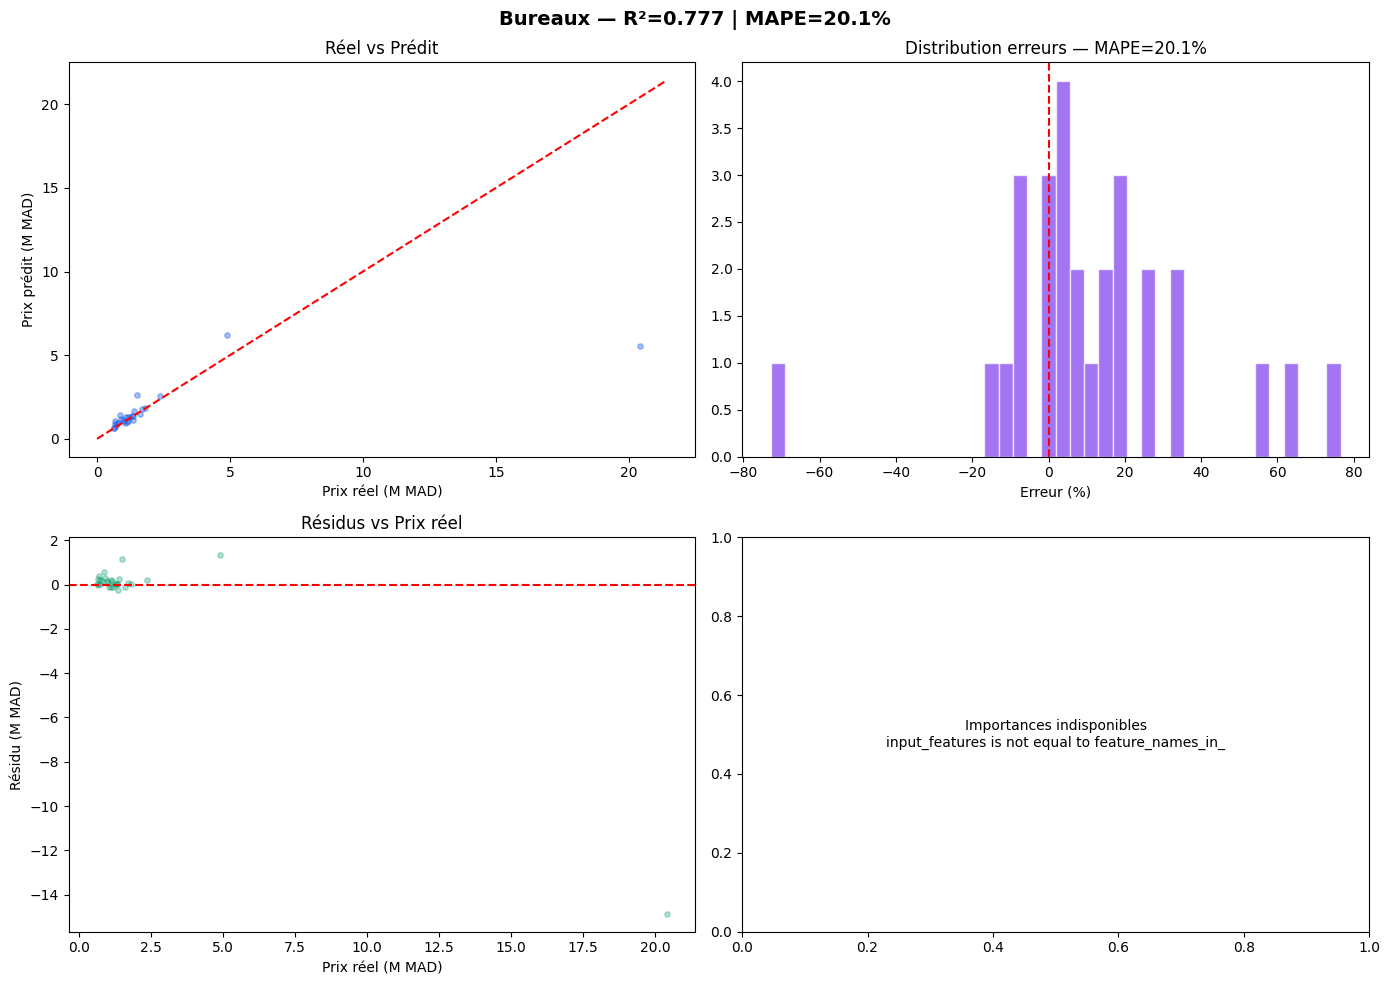

In [14]:
plot_results(pipeline_final, X_test, df_test)


## 9. Analyse erreurs

In [15]:
log_prix_pred = pipeline_final.predict(X_test)
y_pred_mad   = np.exp(log_prix_pred) * df_test["surface_num"].values
y_true_mad   = df_test["prix_num"].values
erreur_pct   = np.abs((y_true_mad - y_pred_mad) / y_true_mad) * 100

df_err = X_test.copy()
df_err["prix_reel"]   = y_true_mad
df_err["prix_predit"] = y_pred_mad
df_err["erreur_pct"]  = erreur_pct
df_err["surface_num"] = df_test["surface_num"].values

print("=== MAPE par zone ===")
print(df_err.groupby("zone_clean")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean",ascending=False).round(1))

print("\n=== MAPE par segment_prix ===")
print(df_err.groupby("segment_prix")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean",ascending=False).round(1))

df_err["tranche"] = pd.cut(df_err["surface_num"],
    bins=[0,30,80,200,500,10000],
    labels=["<30m²","30-80m²","80-200m²","200-500m²",">500m²"])
print("\n=== MAPE par tranche de surface ===")
print(df_err.groupby("tranche",observed=True)["erreur_pct"]
      .agg(["mean","count","median"]).round(1))

print("\n=== Précision par seuil ===")
for s in [10, 20, 30, 50]:
    print(f"  Erreur <= {s:2d}% : {(erreur_pct<=s).mean()*100:.1f}% des cas")


=== MAPE par zone ===
                        mean  count
zone_clean                         
Route de Casablanca  19194.5      1
Médina               13251.8      1
Autre                 9867.3      2
Guéliz                9263.9     17
Issil/Majorelle       8617.8      2
Targa                 8505.7      1
Massira               7133.3      4

=== MAPE par segment_prix ===
                 mean  count
segment_prix                
ultra         14186.4      1
premium       12935.0      5
mid            8412.8     22

=== MAPE par tranche de surface ===
             mean  count   median
tranche                          
30-80m²    6521.8     19   6403.3
80-200m²  15730.3      8  11476.7
>500m²    14186.4      1  14186.4

=== Précision par seuil ===
  Erreur <= 10% : 0.0% des cas
  Erreur <= 20% : 0.0% des cas
  Erreur <= 30% : 0.0% des cas
  Erreur <= 50% : 0.0% des cas


## 10. Sauvegarde

In [16]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)

joblib.dump({"pipeline": pipeline_final, "stats": stats}, MODEL_PATH)
print(f" Modèle sauvegardé       → {MODEL_PATH}")

metadata = {
    "date"           : datetime.now().strftime("%Y-%m-%d"),
    "version"        : "v1_optuna",
    "modele"         : "XGBRegressor",
    "type_bien"      : "bureaux_vente",
    "target"         : "log(prix/m²) → prix = exp(pred) × surface",
    "n_lignes_train" : len(X_train),
    "n_lignes_test"  : len(X_test),
    "n_features"     : X_train.shape[1],
    "n_zones"        : int(df["zone_clean"].nunique()),
    "types_bureaux"   : df["segment_prix"].value_counts().to_dict(),
    "metriques_baseline": {
        "R2"  : round(metrics_baseline["R²"],4),
        "MAPE": round(metrics_baseline["MAPE (%)"],2),
    },
    "metriques_test" : {
        "R2"   : round(metrics_final["R²"],4),
        "MAE"  : round(metrics_final["MAE (MAD)"],0),
        "RMSE" : round(metrics_final["RMSE (MAD)"],0),
        "MAPE" : round(metrics_final["MAPE (%)"],2),
    },
    "cv_r2_optuna"   : round(study.best_value,4),
    "hyperparametres": study.best_params,
    "note"           : "Prix médian 19 400 MAD — kw_industriel signal négatif fort",
}
with open(META_PATH,"w",encoding="utf-8") as f:
    json.dump(metadata,f,ensure_ascii=False,indent=2)
print(f"Métadonnées sauvegardées → {META_PATH}")

df.to_csv(CLEAN_PATH,index=False)
print(f" Dataset sauvegardé      → {CLEAN_PATH}")

print("\n"+"═"*55)
print("  RÉSUMÉ FINAL — BUREAUX VENTE")
print("═"*55)
print(f"  Données          : {len(df):,} bureaux | {df['zone_clean'].nunique()} zones")
print(f"  Features         : {X_train.shape[1]}")
print(f"  R² (test)        : {metrics_final['R²']:.4f}")
print(f"  MAE (test)       : {metrics_final['MAE (MAD)']:,.0f} MAD")
print(f"  MAPE (test)      : {metrics_final['MAPE (%)']:.2f} %")
print(f"  CV R² Optuna     : {study.best_value:.4f}")
print("═"*55)
print(f"\n  Appartements : R²=0.73, MAPE=19% ")
print(f"  Villas       : R²=0.65, MAPE=26% ")
print(f"  Terrains     : R²=0.43, MAPE=65% ")
print(f"  Bureaux       : R²={metrics_final['R²']:.2f}, MAPE={metrics_final['MAPE (%)']:.0f}%")


 Modèle sauvegardé       → ../../model_training/models/xgb_bureaux_vente.pkl
Métadonnées sauvegardées → ../../model_training/models/xgb_bureaux_vente_metadata.json
 Dataset sauvegardé      → ../../data/cleaned_data/vente/bureaux_vente_final.csv

═══════════════════════════════════════════════════════
  RÉSUMÉ FINAL — BUREAUX VENTE
═══════════════════════════════════════════════════════
  Données          : 138 bureaux | 9 zones
  Features         : 45
  R² (test)        : 0.7770
  MAE (test)       : 753,872 MAD
  MAPE (test)      : 20.14 %
  CV R² Optuna     : 0.6661
═══════════════════════════════════════════════════════

  Appartements : R²=0.73, MAPE=19% 
  Villas       : R²=0.65, MAPE=26% 
  Terrains     : R²=0.43, MAPE=65% 
  Bureaux       : R²=0.78, MAPE=20%


In [17]:
# ── Diagnostic leakage / overfitting ──────────────────────────
import numpy as np

# 1. R² train vs test (si R²_train >> R²_test → overfitting)
y_pred_train = pipeline_final.predict(X_train)
y_pred_test  = pipeline_final.predict(X_test)
print(f"R² train : {r2_score(y_train, y_pred_train):.4f}")
print(f"R² test  : {r2_score(y_test,  y_pred_test):.4f}")

# 2. Est-ce que te_lpt_zone (target encoding) est la feature dominante ?
xgb_model = pipeline_final.named_steps["model"]
preproc   = pipeline_final.named_steps["preprocessor"]
try:
    num_cols = list(preproc.transformers_[0][2])
    cat_cols = list(preproc.named_transformers_["cat"].get_feature_names_out(
                    preproc.transformers_[1][2]))
    feat_names = num_cols + cat_cols
    importances = xgb_model.feature_importances_
    top = sorted(zip(feat_names, importances), key=lambda x: -x[1])[:10]
    print("\nTop 10 importances :")
    for name, imp in top:
        print(f"  {name:35s} {imp:.4f}")
except Exception as e:
    print(f"Importances indisponibles : {e}")

# 3. Erreurs % correctement calculées
prix_reel = df_test["prix_num"].values
prix_pred = np.exp(pipeline_final.predict(X_test))
erreurs_pct = np.abs(prix_pred - prix_reel) / prix_reel * 100
print(f"\nErreur médiane : {np.median(erreurs_pct):.1f}%")
print(f"Erreur <= 10%  : {(erreurs_pct <= 10).mean()*100:.1f}%")
print(f"Erreur <= 20%  : {(erreurs_pct <= 20).mean()*100:.1f}%")
print(f"Erreur <= 30%  : {(erreurs_pct <= 30).mean()*100:.1f}%")

R² train : 0.9919
R² test  : 0.7770
Importances indisponibles : input_features is not equal to feature_names_in_

Erreur médiane : 11.9%
Erreur <= 10%  : 46.4%
Erreur <= 20%  : 67.9%
Erreur <= 30%  : 78.6%
